# Hands-on for 2D iterative reconstructions of simulated data with the CASToR platform

## 0. Initializations

Just run it as it is

In [1]:
#
# DO NOT EDIT
#
import matplotlib.pyplot as plt
import csv
import numpy as np
import sys
import os, shlex, subprocess
import math
from interfile import Interfile

workDir='/home/etudiant/TP-ATSI'
simulCmd='/opt/simul/bin/simul_5_64'
castorDir='/opt/castor'

os.environ["LD_LIBRARY_PATH"]="/opt/lib"

if not os.path.isdir(workDir):
    sys.stderr.write(f'Error: work directory {workdir} does not exist')
    sys.exit(1)
elif not os.path.isdir(castorDir):
    sys.stderr.write(f'Error: CASToR directory {castorDir} does not exist')
    sys.exit(1)
elif not os.path.isfile(simulCmd):
    sys.stderr.write(f'Error: simul command {simulCmd} does not exist')
    sys.exit(1)
    
localDir=os.getcwd()

#
# Reconstruction parameters
#
pixelSize=2
pixelNb=128
sliceNb=45
sliceWidth=2*2.78
scanner='PET_GE_SIGNA_PET-MR'
maxRadius=291.4
maxAxialDiff=2.0
ringDiffMax=0
framing='-frm 0:300'
dim='-dim {},{},{}'.format(pixelNb,pixelNb,sliceNb)
vox='-vox {},{},{}'.format(pixelSize,pixelSize,sliceWidth)
proj='-proj joseph'

CRCPPGML = None
NoisePPGML = None


def getNPArrayFromCASToRInterfileHeader(header,path,strict_enforce=True,Verbose=True):
    """
            Routine to extract image from binary file using dictionary build using interfile package.
            Note: a lot of keywords are not implemented, this routine should read interfile for/produced by CASToR
            Positional Parameters:
                - header: dictionary built by interfile package from header (interfile dictionary)
                - path: path of the binary file (string)

            Returns:
                - image (numpy.ndarray)
    """

    ff=''
    CastorKeyList=['name of data file','originating system','PET data type',
             'data format','number format','number of bytes per pixel',
             'Patient name','number of dimensions','image duration',
             'image start time']
    CastorkeyMandatory=[True,False,False,
                   False,False,False,
                   False,True,False,
                   False]
    notHandledList=['data compression', 'data encode',
                   'NUD/rescale slope','NUD/rescale intercept']
    OtherKeys=['slice orientation','orientation','data starting block','data offset in bytes','imagedata byte order','PET data type']

    offset=0
    try:
        for kkey,key in enumerate(CastorKeyList):
            if key not in header.keys():
            #Ensure we have mandatory keys
                if CastorkeyMandatory[kkey]:
                    print(key,header[key]['value'])
                    raise KeyError("No mandatory key {0} ".format(key))
            else:
                if not CastorkeyMandatory[kkey]:
                    if Verbose:
                        print("Optional Key '{0}': {1}".format(key,header[key]['value']))

        for kkey,key in enumerate(notHandledList):
            if key in header.keys():
                if Verbose:
                    print('HND KEY')
                if (header[key]['value'] is not None):
                    print("WARNING: NOT HANDLED NHkey=",header[key]['value'])
                    if strict_enforce:
                        print('STRICT ENFORCE')
                        raise KeyError("Not handled key {0}:{1} ".format(key,header[key]['value']))

        #Get Filename
        filename=os.path.join(path,header['name of data file']['value'])
        if Verbose:
            print('Open {0}'.format(filename))
        #Get Format
        if 'imagedata byte order' in header.keys():
            if(header['imagedata byte order']['value'].lower()=="LITTLEENDIAN".lower()):
                ff+='<'
            elif(header['imagedata byte order']['value'].lower()=="BIGENDIAN".lower()):
                ff+='>'
            else:
                raise TypeError("Unknow order {0}".format(header['imagedata byte order']['value']))
        else:
            if Verbose:
                print("ASSUME LITTLE ENDIAN")
            ff+='<'
        if 'number format' in header.keys():
            if "float" in header['number format']['value'].lower():
                ff+='f'
            elif "signed integer" in header['number format']['value'].lower():
                ff+='i'
            else :
                raise TypeError("Unknow type {0}".format(header['number format']['value']))
        else:
            ff+='f' #default value
        if 'number of bytes per pixel' in header.keys():
            ff+=str(header['number of bytes per pixel']['value'])
        else:
            ff+='4'#default value
        if Verbose:
            print("string format {0}".format(ff))


        #Get Number of dimensions
        ndims=int(header['number of dimensions']['value'])
        lst_dims=[]
        scale_fact=[]
        bnd_or=[]
        fov_sz=[]
        if Verbose:
            print("Ndims=",ndims)
        for kdim in range(1,ndims+1):
            if 'matrix size [{0}]'.format(kdim) not in header.keys():
                if 'matrix size[{0}]'.format(kdim) not in header.keys():
                    raise KeyError("Missing key 'matrix size [{0}]' ".format(kdim))
                else:
                    if Verbose:
                        print("kdim={0}, mat={1}".format(kdim,header['matrix size[{0}]'.format(kdim)]['value']))
                    lst_dims.append(header['matrix size[{0}]'.format(kdim)]['value'])
            else:
                if Verbose:
                    print("kdim={0}, mat={1}".format(kdim,header['matrix size [{0}]'.format(kdim)]['value']))
                lst_dims.append(header['matrix size [{0}]'.format(kdim)]['value'])
            if 'scaling factor (mm/pixel) [{0}]'.format(kdim) in header.keys():
                scale_fact.append(header['scaling factor (mm/pixel) [{0}]'.format(kdim)]['value'])
            if 'bounding origin (mm) [{0}]'.format(kdim) in header.keys():
                bnd_or.append(header['bounding origin (mm) [{0}]'.format(kdim)]['value'])
            if 'FOV size (mm) [{0}]'.format(kdim) in header.keys():
                fov_sz.append(header['FOV size (mm) [{0}]'.format(kdim)]['value'])
        lst_dims.reverse()
        if len(scale_fact)>0:
            scale_fact.reverse()
        if len(bnd_or)>0:
            bnd_or.reverse()
        if len(fov_sz)>0:
            fov_sz.reverse()
        if Verbose:
            print("lst_dims=",lst_dims)
        ktotal=1
        for kd in lst_dims:
            ktotal*=kd

        if 'data starting block' in header.keys():
            offset=2048*header['data starting block']['value']
            if Verbose:
                print("offset={0}".format(offset))
        elif 'data offset in bytes' in header.keys():
            offset=header['data offset in bytes']['value']
            if Verbose:
                print("offset={0}".format(offset))

        #Read all binary file and reshape it
        with open(filename, 'rb') as f:
            f.seek(offset)
            data=np.fromfile(f,dtype=ff,count=ktotal)
        data=np.reshape(data,lst_dims,order='C')
        for kk,key in enumerate(header.keys()):
            if 'data format' in key.lower():
                if Verbose:
                    print(header[key]['value'])
                # if('image' not in header[key]['value'].lower()):
                #     tmp=lst_dims[ndims-2]
                #     lst_dims[ndims-2]=lst_dims[ndims-1]
                #     lst_dims[ndims-1]=tmp
                #     data=np.swapaxes(data, ndims-2, ndims-1)
                #     if(len(scale_fact)==ndims):
                #         tmp=scale_fact[ndims-2]
                #         scale_fact[ndims-2]=scale_fact[ndims-1]
                #         scale_fact[ndims-1]=tmp
                #     if(len(bnd_or)==ndims):
                #         tmp=bnd_or[ndims-2]
                #         bnd_or[ndims-2]=bnd_or[ndims-1]
                #         bnd_or[ndims-1]=tmp
                #     if(len(fov_sz)==ndims):
                #         tmp=fov_sz[ndims-2]
                #         fov_sz[ndims-2]=fov_sz[ndims-1]
                #         fov_sz[ndims-1]=tmp
            if 'orientation' in key.lower():
                if Verbose:
                    print("Optional Key '{0}': {1}".format(key,header[key]['value']))
                   #Transverse[default]|Coronal|Sagittal|
        if Verbose:
            print("Ndims: {0}".format(ndims))
            print("Dimensions: {0}".format(lst_dims))
        return data

    except Exception as inst:
        print(inst)
        print("EXCEPTION RAISED")
        return -1

## 1. Definition and generation of the phantom
    
    Background disk with smaller contrast disks
    
    Generate both an ASCII file describing the phantom and a pixelized image of the phantom 
    
    Specify:
     - the radius of the background disk in mm (radius), default = 100
     - the emission density of the contrast disks relative to the background (sphereValues), default = 8 disks, from 4.0 to 0.0 


Generation of the phantom, called cylinder
 ... wait ...
Phantom image saved in /home/etudiant/TP-ATSI/cylinder.i


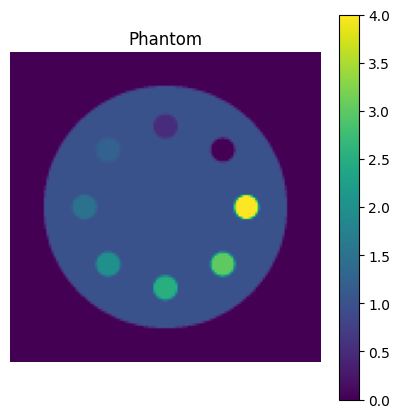

In [2]:
#
# Definition and generatin of the phantom
#
# Dimensions in mm
#
# Description of the phantom
phantom='cylinder'
radius=100.0
sphereValues=[4.,3.,2.5,2.,1.5,1.25,0.5,0.0]
backgroundValue=1.0
#
# DO NOT EDIT BELOW
#
print(f'Generation of the phantom, called {phantom}')
print(' ... wait ...')
sphereNb=len(sphereValues)
for i in range(sphereNb):
    sphereValues[i] *= backgroundValue
sphereRadius=10.0
sphereCoordinates=np.zeros((sphereNb,3))
a=2.0*radius/3.0
for i in range(sphereNb):
    sphereCoordinates[i,0] = a*math.cos(i*2*math.pi/sphereNb)
    sphereCoordinates[i,1] = a*math.sin(i*2*math.pi/sphereNb)
    sphereCoordinates[i,2] = 0.0 
sphereCoordinates = np.around(sphereCoordinates,decimals=2)
phantomFileName = f'{workDir}/{phantom}.data'
phantomImgFileName = f'{workDir}/{phantom}.i'
with open(phantomFileName,'w',encoding="utf-8") as f:
  f.write('phantom\n')
  f.write('object: cylinder\ncenter 0.0 0.0 0.0\nhalf-axis {} {} 0.0\nemission {}\nattenuation 0.0096\n'.format(radius,radius,backgroundValue))
  f.write('label 1\n')
  for i in range(sphereNb):
    f.write('\nobject: {}\n'.format(sphereValues[i]))
    f.write('center {} {} {}\n'.format(sphereCoordinates[i,0],sphereCoordinates[i,1],sphereCoordinates[i,2]))
    f.write('half-axis {} {} 0.0\n'.format(sphereRadius,sphereRadius))
    f.write('emission {}\n'.format(sphereValues[i]-backgroundValue))
    f.write('label {}\n'.format(i+2))
    i+=1
  f.write('end\n')
cmd=f'{simulCmd} -i {phantomFileName} -o {phantomImgFileName} -m 805 -I --outputformat=interfile -z 2.7773485 -O 3 --disableHalfPixelOffset'
args = shlex.split(cmd)
p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
p.wait()
stdout,stderr = p.communicate()
if p.returncode != 0:
    sys.stderr.write(f'Error with {cmd}:')
    sys.stderr.write(str(stderr.decode('utf-8'))) 
    sys.exit(1)
if not os.path.exists(phantomImgFileName):
    sys.stderr.write(f'Error with {cmd}:')
    sys.stderr.write(f'No output phantom image file {phantomImgFileName}') 
    sys.exit(1)
print(f'Phantom image saved in {phantomImgFileName}')
hdr=Interfile.load(f'{phantomImgFileName}.hdr')
imgPhantom=getNPArrayFromCASToRInterfileHeader(hdr,workDir,strict_enforce=True,Verbose=False)
fig, ax = plt.subplots(figsize=[5,5])
ims=ax.imshow(imgPhantom[0,:,:])
fig.colorbar(ims,ax=ax)
ax.set_axis_off()
ax.set_title('Phantom')
plt.show()
hdr = None
imgPhantom = None

## 2. Simulation and reconstruction of a noisefree sinogram

Simulation of noisefree data for phantom cylinder using scanner geometry PET_GE_SIGNA_PET-MR
 ... wait ...
Noisefree sinogram saved in /home/etudiant/TP-ATSI/CASToR-proj-cylinder/CASToR-proj-cylinder_ana.Cdh
Reconstruction of the noisefree data with MLEM for 12 iterations and 14 subsets
 ... wait ...


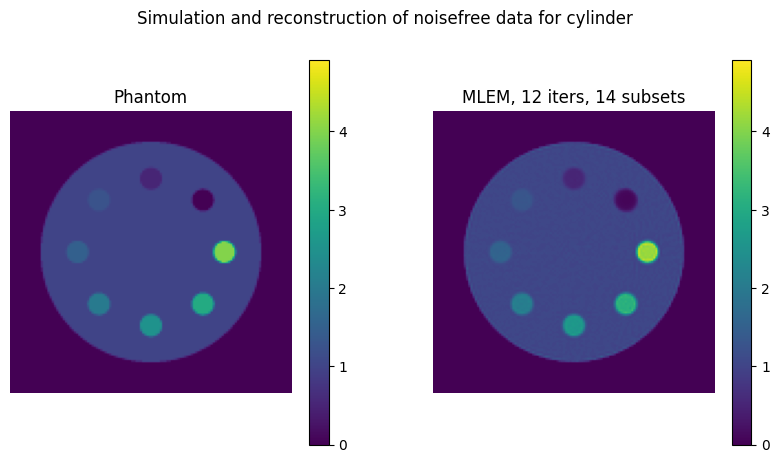

In [3]:
opti='MLEM'
iterNb=12
subsetNb=14
iterations=f'-it {iterNb}:{subsetNb}'
#
simulDir=f'{workDir}/CASToR-proj-{phantom}'
name=f'{phantom}_ana'
simulAnaDataFile=f'{simulDir}/CASToR-proj-{name}.Cdh'
reconAnaDir=f'{workDir}/CASToR-recon-{name}'
reconAnaFile=f'{reconAnaDir}/CASToR-recon-{name}_it{iterNb}.hdr'
#
# Simulation of noisefree data
#
print(f'Simulation of noisefree data for phantom {phantom} using scanner geometry {scanner}')
print(' ... wait ...')
if not os.path.exists(phantomFileName):
    sys.stderr.write(f'Error: phantom file {phantomFileName}.data does not exist')
    sys.exit(1)
cmd=f'{castorDir}/bin/castor-proj -dout {simulDir} -vb 1 -th 0 -sc {scanner} -PET_maxRadialLORmm {maxRadius}'
cmd=f'{cmd} -PET_maxAxialDiffmm {maxAxialDiff} -PET_isotope F-18 -phantom {phantomFileName}'
cmd=f'{cmd} -atn -oversampling 3 {framing} -conf {castorDir}/config'
args = shlex.split(cmd)
p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
p.wait()
stdout,stderr = p.communicate()
if p.returncode != 0:
    sys.stderr.write(f'Error with {cmd}:')
    sys.stderr.write(str(stderr.decode('utf-8'))) 
    sys.exit(1)
print(f'Noisefree sinogram saved in {simulAnaDataFile}')
#
# Reconstruction of the simulated noisefree sinogram
#
print(f'Reconstruction of the noisefree data with {opti} for {iterNb} iterations and {subsetNb} subsets')
print(' ... wait ...')
if not os.path.exists(simulAnaDataFile):
    sys.stderr.write(f'Error: noisefree data file {simulAnaDataFile} does not exist')
    sys.exit(1)
cmd=f'{castorDir}/bin/castor-recon -df {simulAnaDataFile} -dout {reconAnaDir} -opti {opti} -it {iterNb}:{subsetNb} {dim} {vox}'
cmd=f'{cmd} -th 0 -vb 1 {proj} {framing} -proj-common 3,0,0 -conf {castorDir}/config'
args = shlex.split(cmd)
p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
p.wait()
stdout,stderr = p.communicate()
if p.returncode != 0:
    sys.stderr.write(f'Error with {cmd}:')
    sys.stderr.write(str(stderr.decode('utf-8'))) 
    sys.exit(1)
if not os.path.exists(reconAnaFile):
    sys.stderr.write(f'Error: reconstruction file of the noisefree data {reconAnaFile} does not exist')
    sys.exit(1)
#
# Visualization
#
NbCols=2
fig, ax = plt.subplots(1,NbCols,figsize=[5*NbCols,5])
vmax=1.23*np.max(sphereValues)
hdr=Interfile.load(f'{phantomImgFileName}.hdr')
imgPhantom=getNPArrayFromCASToRInterfileHeader(hdr,workDir,strict_enforce=True,Verbose=False)
imp=ax[0].imshow(imgPhantom[0,:,:],vmax=vmax)
fig.colorbar(imp,ax=ax[0])
ax[0].set_axis_off()
ax[0].set_title('Phantom')
hdr=Interfile.load(reconAnaFile)
imgAnaRecon=getNPArrayFromCASToRInterfileHeader(hdr,reconAnaDir,strict_enforce=True,Verbose=False)
ima=ax[1].imshow(imgAnaRecon[0,:,:],vmax=vmax)
fig.colorbar(ima,ax=ax[1])
ax[1].set_axis_off()
ax[1].set_title(f'{opti}, {iterNb} iters, {subsetNb} subsets')
fig.suptitle(f'Simulation and reconstruction of noisefree data for {phantom}')
plt.show()

## 3. Simulation and reconstruction of noisy data

***Select the number of events (eventsNb) such as to get a raisonably noisy image***

  - Optimization algorithm: MLEM, 14 subsets, 4 iterations (default values in clinics)

Noisy simulation of phantom cylinder for 1.00E+06 events
 ... wait ...
Noisy sinogram with 1.00E+06 events saved in /home/etudiant/TP-ATSI/CASToR-proj-cylinder/CASToR-proj-cylinder_1000000_noise.Cdh
Reconstruction with MLEM of the noisy sinogram with 1.00E+06 events
 ... wait ...


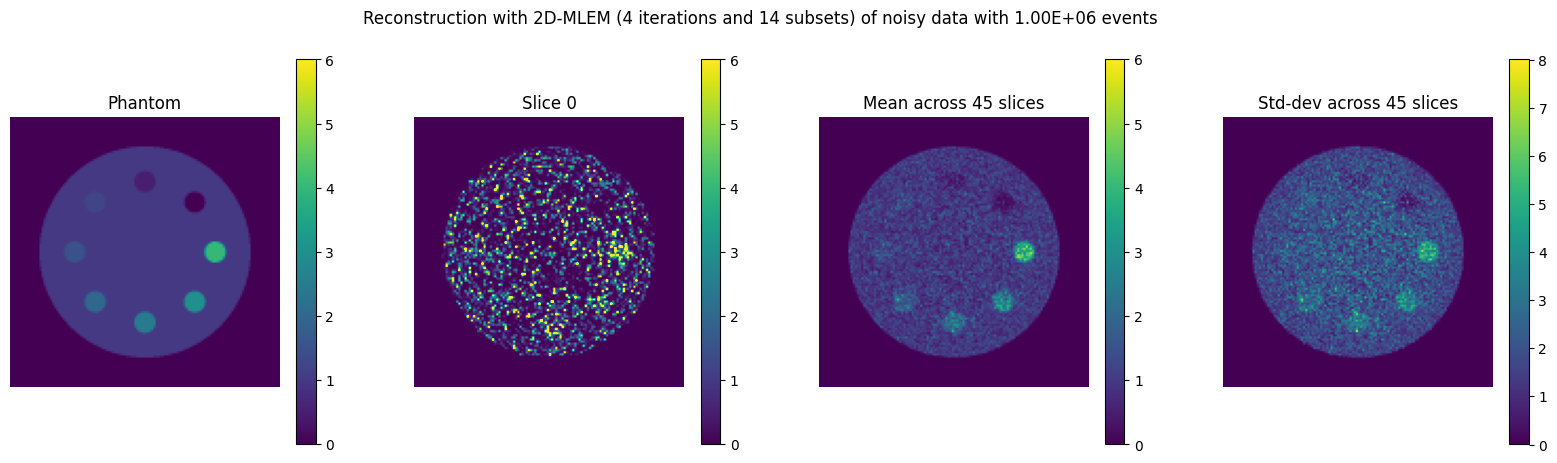

Figure saved in cylinder_1000000e_MLEM_s14i4.png


In [4]:
eventsNb=10**6
#
# Reconstruction parameters: optimization algorithm, penalty
#
iterNb=4
subsetNb=14
opti='MLEM' # \in ['MLEM','PPGML']
penalty=None # \in [None,'quadratic','huber','nuyts'] 
bowsher=None # \in [None,1]
beta=0 # \in [1,10] if penalty is not None
#
optiName=opti
if penalty is not None:
    if opti == 'MLEM':
        sys.stderr.write(f'Error: MLEM can not be run with a penalty term ({penalty})')
        sys.exit(1)
    penaltyFile='MRF.conf'
    optiName=optiName+f'-{penalty}-beta{beta}'
    with open(penaltyFile,'w',encoding="utf-8") as f:
        if penalty == 'quadratic':
            f.write('potential function: quadratic\n')
        elif penalty == 'huber':
             f.write('potential function: huber piecewise\n')
             f.write('deltaHuber: 0.1\n')
        elif penalty == 'nuyts': 
             f.write('potential function: nuyts relative\n')
             f.write('gammaRD: 2\n')   
        else:
            sys.stderr.write(f'Error: penalty function {penalty} is not recognized')
            sys.exit(1)
        f.write('neighborhood shape: sphere\n')
        f.write('sphere neighborhood radius (mm): 6\n')
        f.write('proximity factor: euclidian\n')
        if bowsher is None:
            f.write('similarity factor: none\n')
        else:
            f.write('similarity factor: aBowsher\n')
            f.write('similarity threshold Bowsher (%): 40.\n')
            optiName=optiName+'-bowsher'
#        
name=f'{phantom}_{eventsNb}_noise'
simulNoiseDataFile=f'{simulDir}/CASToR-proj-{name}.Cdh'
reconName=name+optiName
reconNoiseDir=f'{workDir}/CASToR-recon-{reconName}'
reconNoiseFile=f'{reconNoiseDir}/CASToR-recon-{reconName}_it{iterNb}.hdr'
#
print(f'Noisy simulation of phantom {phantom} for {eventsNb:.2E} events')
print(' ... wait ...')
if not os.path.exists(simulDir):
    sys.stderr.write(f'Error: simulation directory {simuldir} does not exist')
    sys.exit(1)
cmd=f'{castorDir}/bin/castor-proj -dout {simulDir} -vb 1 -th 0 -noiseSuffix {eventsNb}'
cmd=f'{cmd} -trues {eventsNb} -conf {castorDir}/config'
args = shlex.split(cmd)
p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
p.wait()
stdout,stderr = p.communicate()
if p.returncode != 0:
    sys.stderr.write(f'Error with {cmd}:')
    sys.stderr.write(str(stderr.decode('utf-8'))) 
    sys.exit(1)
elif not os.path.exists(simulNoiseDataFile):
    sys.stderr.write(f'Error: noisy sinogram  with {eventsNb} data file {simulNoiseDataFile} does not exist')
    sys.exit(1)    
print(f'Noisy sinogram with {eventsNb:.2E} events saved in {simulNoiseDataFile}')
#
print(f'Reconstruction with {optiName} of the noisy sinogram with {eventsNb:.2E} events')
print(' ... wait ...')
cmd=f'{castorDir}/bin/castor-recon -df {simulNoiseDataFile} -dout {reconNoiseDir} -opti {opti} -it {iterNb}:{subsetNb}  {dim} {vox}'
cmd=f'{cmd} -th 0 -vb 1 {proj} {framing} -proj-common 3,0,0 -conf {castorDir}/config'
if penalty is not None:
    cmd=cmd+f' -pnlt MRF:{penaltyFile} -pnlt-beta {beta}'
    if bowsher is not None:
        cmd=cmd+f' -multimodal {reconAnaFile}'
args = shlex.split(cmd)
p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
p.wait()
stdout,stderr = p.communicate()
if p.returncode != 0:
    sys.stderr.write(f'Error with {cmd}:')
    sys.stderr.write(str(stderr.decode('utf-8'))) 
    sys.exit(1)
if not os.path.exists(reconNoiseFile):
    sys.stderr.write(f'Error: reconstruction file of the noisy sinogram with {eventsNb} {reconNoiseFile} does not exist')
    sys.exit(1)
#
NbCols=4
fig, ax = plt.subplots(1,NbCols,figsize=[5*NbCols,5])
vmax=1.5*np.max(sphereValues)
hdr=Interfile.load(f'{phantomImgFileName}.hdr')
imgPhantom=getNPArrayFromCASToRInterfileHeader(hdr,workDir,strict_enforce=True,Verbose=False)
imp=ax[0].imshow(imgPhantom[0,:,:],vmax=vmax)
fig.colorbar(imp,ax=ax[0])
ax[0].set_axis_off()
ax[0].set_title('Phantom')
hdr=Interfile.load(reconNoiseFile)
imgNoiseRecon=getNPArrayFromCASToRInterfileHeader(hdr,reconNoiseDir,strict_enforce=True,Verbose=False)
slice=0
imn=ax[1].imshow(imgNoiseRecon[slice,:,:],vmax=vmax)
fig.colorbar(imn,ax=ax[1])
ax[1].set_axis_off()
ax[1].set_title(f'Slice {slice}')
imgNoiseReconMean=np.mean(imgNoiseRecon,axis=0)
imm=ax[2].imshow(imgNoiseReconMean,vmax=vmax)
fig.colorbar(imm,ax=ax[2])
ax[2].set_axis_off()
ax[2].set_title(f'Mean across {sliceNb} slices')
imgNoiseReconStd=np.std(imgNoiseRecon,axis=0)
ims=ax[3].imshow(imgNoiseReconStd)
fig.colorbar(ims,ax=ax[3])
ax[3].set_axis_off()
ax[3].set_title(f'Std-dev across {sliceNb} slices')
plt.suptitle(f'Reconstruction with 2D-{optiName} ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events')
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i{iterNb}.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')

**On change le nombre d'événements pour avoir une image bruitée. On utilisera cette valeur pour le reste du TP.**

## 4. Effect of the number of iterations for the ML-EM algorithm for noisy data

For the number of events selected above, the 45 slices are reconstructed independently in 2D. 
Each slice can therefore be considered as independant.
The mean and the standard-deviation images are computed from the 45 slices. 

Qualitative assesment: evaluate visually the quality of the images (single slice, mean and standard-deviation images) as a function of the number of iterations.

Quantitative assesment: evaluation of the signal versus noise trade-offs as a function of the number of iterations. Discuss the trends of the curves and the differences in convergence between positive contrast (activty > background) and negative contrast (activity < background).

Figures of merit for the signal and the noise:
* Signal: Contrast Recovery Coefficient (CRC) of the contrast disks, measured on the mean image. Constrast is defined as the ratio between (diskActivity - backgroundActivity) and (backgroundActivity). The recovery coefficient is the ratio betwenn the measured contrast and the nominal contrast.  
* Noise: Mean value in the center of the background, measured in the standard-deviation image. 

Reconstruction default parameters:
* MLEM: opti='MLEM'
* Number of iterations: iterNb=24
* Number of subsets (OSEM): subsetNb=7



Reconstruction with MLEM of the noisy sinogram with 1.00E+06 events
 ... wait ...


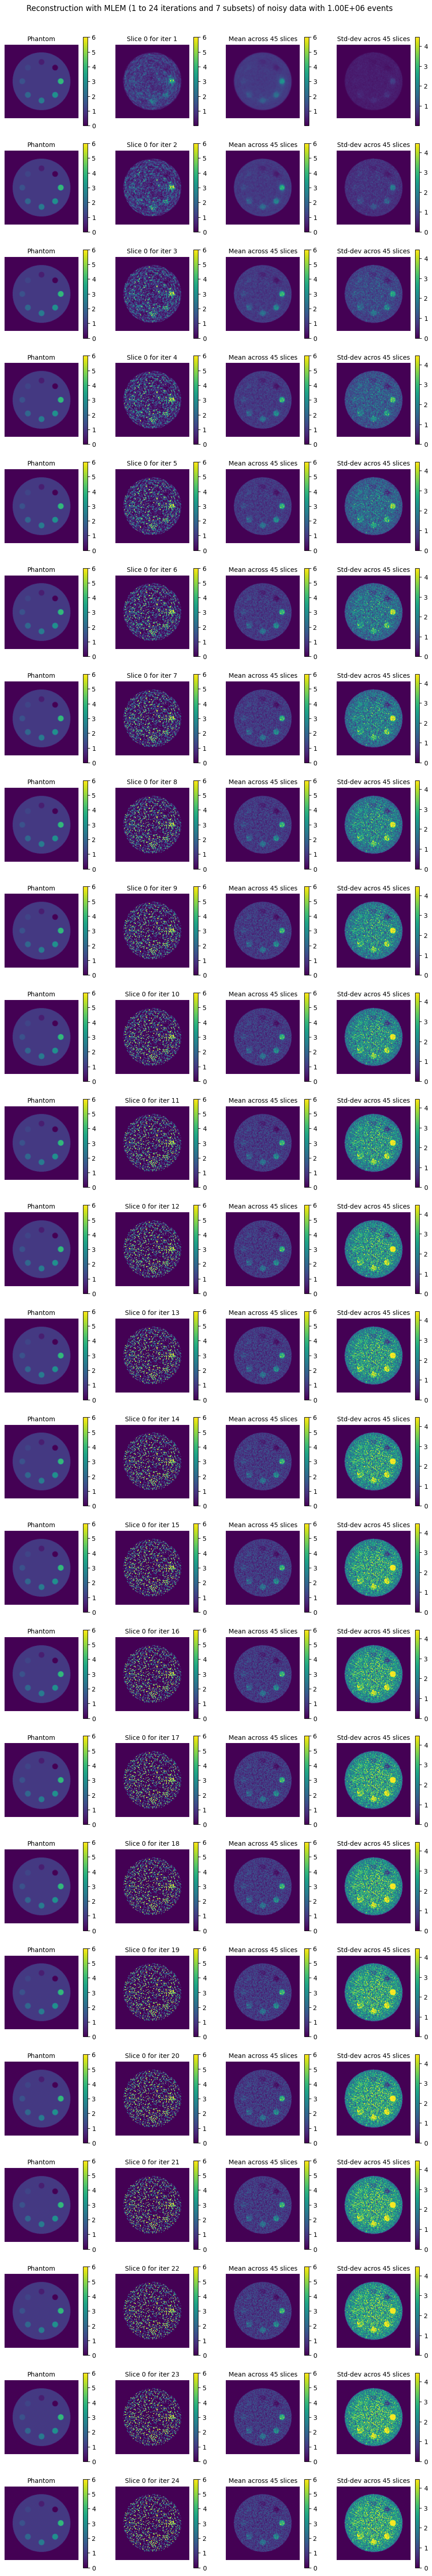

Figure saved in cylinder_1000000e_MLEM_s7i1-24.png


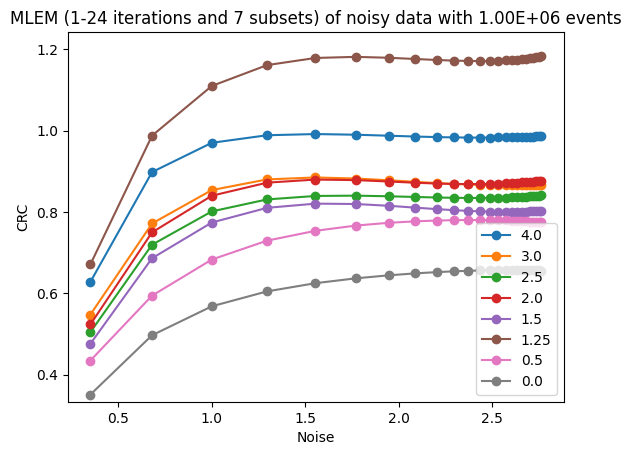

Figure saved in cylinder_1000000e_MLEM_s7i1-24_CRCvsNoise.png


In [7]:
#
# Reconstruction parameters: optimization algorithm, penalty
#
iterNb=24
subsetNb=7
opti='MLEM' # \in ['MLEM','PPGML']
penalty=None # \in [None,'quadratic','huber','nuyts'] 
bowsher=None # \in [None,1]
beta=0 # \in [1,10] if penalty is not None
#
optiName=opti
if penalty is not None:
    if opti == 'MLEM':
        sys.stderr.write(f'Error: MLEM can not be run with a penalty term ({penalty})')
        sys.exit(1)
    penaltyFile='MRF.conf'
    optiName=optiName+f'-{penalty}-beta{beta}'
    with open(penaltyFile,'w',encoding="utf-8") as f:
        if penalty == 'quadratic':
            f.write('potential function: quadratic\n')
        elif penalty == 'huber':
             f.write('potential function: huber piecewise\n')
             f.write('deltaHuber: 0.1\n')
        elif penalty == 'nuyts': 
             f.write('potential function: nuyts relative\n')
             f.write('gammaRD: 2\n')   
        else:
            sys.stderr.write(f'Error: penalty function {penalty} is not recognized')
            sys.exit(1)
        f.write('neighborhood shape: sphere\n')
        f.write('sphere neighborhood radius (mm): 6\n')
        f.write('proximity factor: euclidian\n')
        if bowsher is None:
            f.write('similarity factor: none\n')
        else:
            f.write('similarity factor: aBowsher\n')
            f.write('similarity threshold Bowsher (%): 40.\n')
            optiName=optiName+'-bowsher'
#        
reconName=name+optiName
reconNoiseDir=f'{workDir}/CASToR-recon-{reconName}'
#
if not os.path.exists(simulNoiseDataFile):
    sys.stderr.write(f'Error: noisy sinogram  with {eventsNb} data file {simulNoiseDataFile} does not exist')
    sys.exit(1)    
print(f'Reconstruction with {optiName} of the noisy sinogram with {eventsNb:.2E} events')
print(' ... wait ...')
cmd=f'{castorDir}/bin/castor-recon -df {simulNoiseDataFile} -dout {reconNoiseDir} -opti {opti} -it {iterNb}:{subsetNb}  {dim} {vox}'
cmd=f'{cmd} -th 0 -vb 1 {proj} {framing} -proj-common 3,0,0 -conf {castorDir}/config'
if penalty is not None:
    cmd=cmd+f' -pnlt MRF:{penaltyFile} -pnlt-beta {beta}'
    if bowsher is not None:
        cmd=cmd+f' -multimodal {reconAnaFile}'
args = shlex.split(cmd)
p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
p.wait()
stdout,stderr = p.communicate()
if p.returncode != 0:
    sys.stderr.write(f'Error with {cmd}:')
    sys.stderr.write(str(stderr.decode('utf-8'))) 
    sys.exit(1)
reconNoiseFile=f'{reconNoiseDir}/CASToR-recon-{reconName}_it{iterNb}.hdr'
if not os.path.exists(reconNoiseFile):
    sys.stderr.write(f'Error: reconstruction file of the noisy sinogram with {eventsNb} {reconNoiseFile} does not exist')
    sys.exit(1)
#
# Figures
#
NbCols=4
NbRows=int(iterNb)
fig, ax = plt.subplots(NbRows,NbCols,figsize=[3*NbCols,3*NbRows])
vmax=1.5*np.max(sphereValues)
CRCMLEM = np.zeros((sphereNb,iterNb))
NoiseMLEM = np.zeros(iterNb)
iRadius = round(sphereRadius/pixelSize)+1
titleSize=10
slice=0
for iter in range(iterNb,0,-1):
    row=iter-1
    hdr=Interfile.load(f'{phantomImgFileName}.hdr')
    imgPhantom=getNPArrayFromCASToRInterfileHeader(hdr,workDir,strict_enforce=True,Verbose=False)
    imp=ax[row,0].imshow(imgPhantom[0,:,:],vmax=vmax)
    fig.colorbar(imp,ax=ax[row,0])
    ax[row,0].set_axis_off()
    ax[row,0].set_title('Phantom',size=titleSize)
    reconNoiseFile=f'{reconNoiseDir}/CASToR-recon-{reconName}_it{iter}.hdr'
    hdr=Interfile.load(reconNoiseFile)
    imgNoiseRecon=getNPArrayFromCASToRInterfileHeader(hdr,reconNoiseDir,strict_enforce=True,Verbose=False)
    imn=ax[row,1].imshow(imgNoiseRecon[slice,:,:],vmax=vmax)
    fig.colorbar(imn,ax=ax[row,1])
    ax[row,1].set_axis_off()
    ax[row,1].set_title(f'Slice {slice} for iter {iter}',size=titleSize)
    imgNoiseReconMean=np.mean(imgNoiseRecon,axis=0)
    imm=ax[row,2].imshow(imgNoiseReconMean,vmax=vmax)
    fig.colorbar(imm,ax=ax[row,2])
    ax[row,2].set_axis_off()
    ax[row,2].set_title(f'Mean across {sliceNb} slices',size=titleSize)
    imgNoiseReconStd=np.std(imgNoiseRecon,axis=0)
    if iter == iterNb:
        vmaxStd=0.1*np.max(imgNoiseRecon)
    ims=ax[row,3].imshow(imgNoiseReconStd,vmax=vmaxStd)
    fig.colorbar(ims,ax=ax[row,3])
    ax[row,3].set_axis_off()
    ax[row,3].set_title(f'Std-dev acros {sliceNb} slices',size=titleSize)
    #
    # ROI analysis
    #
    #  Background in the cylinder center
    ixc=round(0.5*pixelNb-0.5)
    iyc=round(0.5*pixelNb-0.5)
    n=0
    roiBackgroundMeanValue=0.0
    roiBackgroundStdValue=0.0
    for ix in range(ixc-iRadius,ixc+iRadius+1,1):
        x = pixelSize*(ix+0.5-pixelNb/2.0)
        for iy in range(iyc-iRadius,iyc+iRadius+1,1):
            y = pixelSize*(iy+0.5-pixelNb/2.0)
            r = math.sqrt((x)**2+(y)**2)
            if r < sphereRadius:
                n+=1
                roiBackgroundMeanValue+=imgNoiseReconMean[iy,ix]
                roiBackgroundStdValue+=imgNoiseReconStd[iy,ix]
    roiBackgroundMeanValue/=n
    roiBackgroundStdValue/=n
    NoiseMLEM[iter-1]=roiBackgroundStdValue/roiBackgroundMeanValue
    for i in range(sphereNb):
        ixc=int(round(0.5*pixelNb+sphereCoordinates[i,0]/pixelSize-0.5))
        iyc=int(round(0.5*pixelNb+sphereCoordinates[i,1]/pixelSize-0.5))
        n=0
        roiMeanValue=0.0
        roiStdValue=0.0
        for ix in range(ixc-iRadius,ixc+iRadius+1,1):
            x = pixelSize*(ix+0.5-pixelNb/2.0)
            for iy in range(iyc-iRadius,iyc+iRadius+1,1):
                y = pixelSize*(iy+0.5-pixelNb/2.0)
                r = math.sqrt((x-sphereCoordinates[i,0])**2+(y-sphereCoordinates[i,1])**2)
                if r < 0.9*sphereRadius:
                    n+=1
                    roiMeanValue+=imgNoiseReconMean[iy,ix]
                    roiStdValue+=imgNoiseReconStd[iy,ix]
        roiMeanValue/=n
        roiStdValue/=n
        CRCMLEM[i,iter-1]=(roiMeanValue/roiBackgroundMeanValue-1)/(sphereValues[i]/backgroundValue-1)
    # print(f'Iteration {iter}, CRC = {CRCMLEM[0,iter-1]}, noise = {NoiseMLEM[iter-1]}')
plt.suptitle(f'Reconstruction with {optiName} (1 to {iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events',y=0.89)
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i1-{iterNb}.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')
fig, ax = plt.subplots()
for i in range(sphereNb):
    ax.plot(NoiseMLEM[:],CRCMLEM[i,:],'o',ls='-',label=f'{sphereValues[i]/backgroundValue}')
ax.set(xlabel='Noise', ylabel='CRC',title=f'{optiName} (1-{iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events')
ax.set_ylim((0.95*np.min(CRCMLEM),1.05*np.max(CRCMLEM)))
plt.legend(loc='lower right')
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i1-{iterNb}_CRCvsNoise.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')

**On remarque que la vitesse de convergence n'est pas la même pour les différents sous-ensembles. On remarque que l'un des sous-ensemble présente des artefacts, ce qui fait que le CRC dépasse 1. On remarque également que l'estimateur devient moins précis au fil des itérations**

## 4. Effect of the prior and the hyper-parameter value (beta) for the MAP algorithm for noisy data

Evaluation of MAP reconstructions for the three different potential functions for the Markov random field prior (page 140):
* Quadratic
* Huber
* Relative difference

For the number of events selected above, the 45 slices are reconstructed independently in 2D. 
Each slice can therefore be considered as independant.
The mean and the standard-deviation images are computed from the 45 slices. 

Qualitative assesment: evaluate visually the quality of the images (single slice, mean and standard-deviation images) as a function of the value of the hyper-parameter beta and the potential function

Quantitative assesment: evaluation of the signal versus noise trade-offs as a function of the hyper-parameter beta. If beta equals zero, what does it mean? 

Discuss the differences between MLEM and MAP

Discuss the differences betwwen the different priors (potential functions) 

Figures of merit for the signal and the noise:
* Signal: Contrast Recovery Coefficient (CRC) of the contrast disks, measured on the mean image. Constrast is defined as the ratio between (diskActivity - backgroundActivity) and (backgroundActivity). The recovery coefficient is the ratio betwenn the measured contrast and the nominal contrast.  
* Noise: Mean value in the center of the background, measured in the standard-deviation image. 

Reconstruction default parameters:
* MLEM: opti='PPGML'
* Number of iterations: iterNb=24
* Number of subsets (OSEM): subsetNb=7
* Values of the hyper-parameter, beta. It depends on the number of events. It ranges from 0 to betaMax such as the noise at betaMax is similar to the noise with ML-EM after one iteration. Example of values: betas=[0,0.125,0.5,2.0,9.0]. Always use the same number of beta values.
* penalty: 'quadratic' or 'huber' or 'nuyts'
* Anatomical prior: bowsher=None

### Discuss the effect of an anatomical prior

Reconstruction with matched anatomical prior:
* MLEM: opti='PPGML'
* Number of iterations: iterNb=24
* Number of subsets (OSEM): subsetNb=7
* Values of the hyper-parameter, beta. It depends on the number of events. It ranges from 0 to betaMax such as the noise at betaMax is similar to the noise with ML-EM after one iteration. Example of values: betas=[0,0.125,0.5,2.0,9.0]. Always use the same number of beta values.
* penalty: 'quadratic'
* Anatomical prior: bowsher=1


Reconstructions with PPGML-quadratic of the noisy sinogram with 1.00E+06 events
 ... wait for beta = 0...
Beta 0, CRC = 0.9861354825431631, noise = 2.762949479953279
 ... wait for beta = 0.125...
Beta 0.125, CRC = 0.9570872545871526, noise = 0.7177437327257304
 ... wait for beta = 0.5...
Beta 0.5, CRC = 0.7719630162830421, noise = 0.3210015263093857
 ... wait for beta = 2.0...
Beta 2.0, CRC = 0.5238090246897875, noise = 0.13261753010230565
 ... wait for beta = 9.0...
Beta 9.0, CRC = 0.2978114481540511, noise = 0.04976608557219129


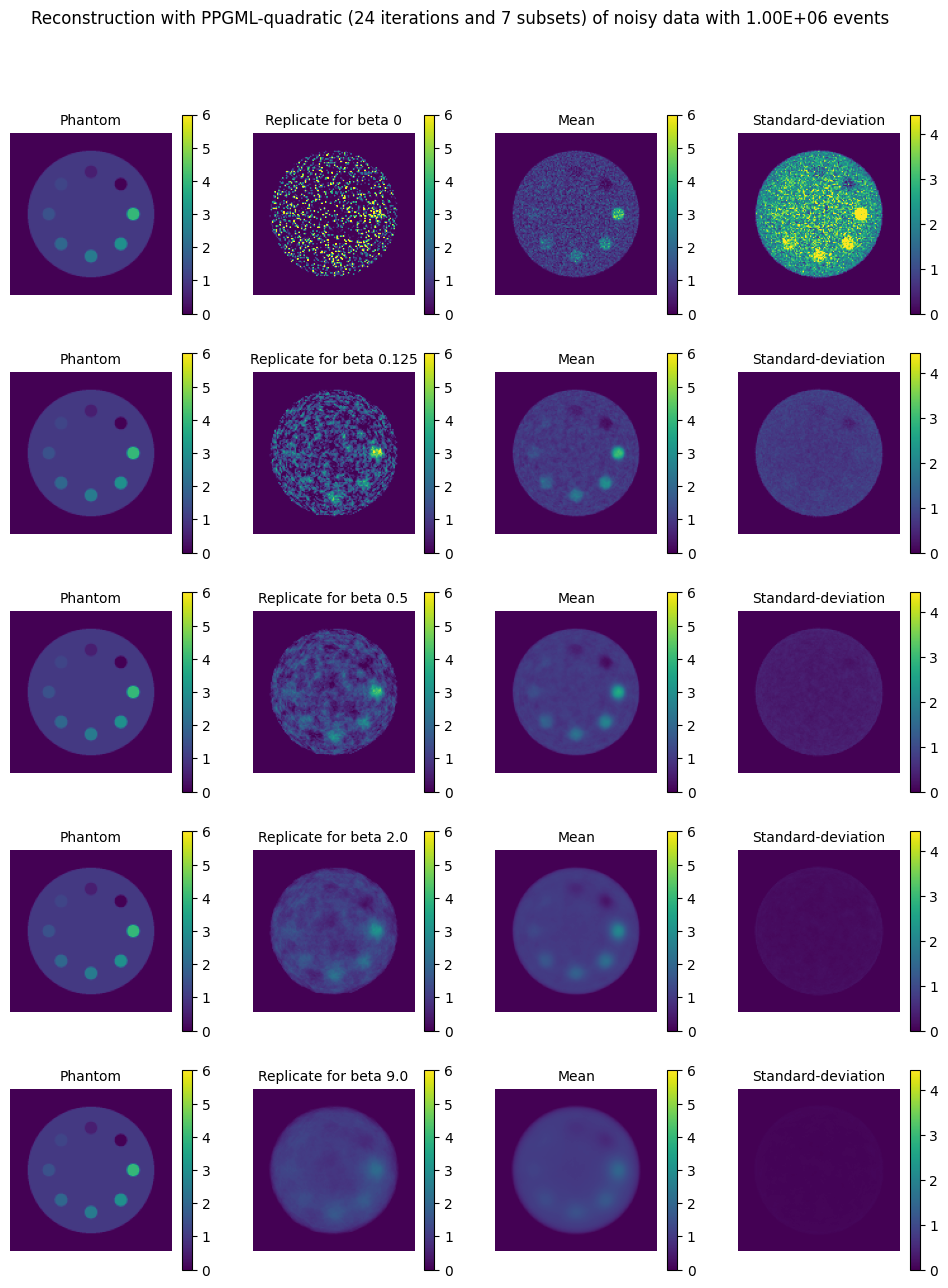

Figure saved in cylinder_1000000e_PPGML-quadratic_s7i24.png


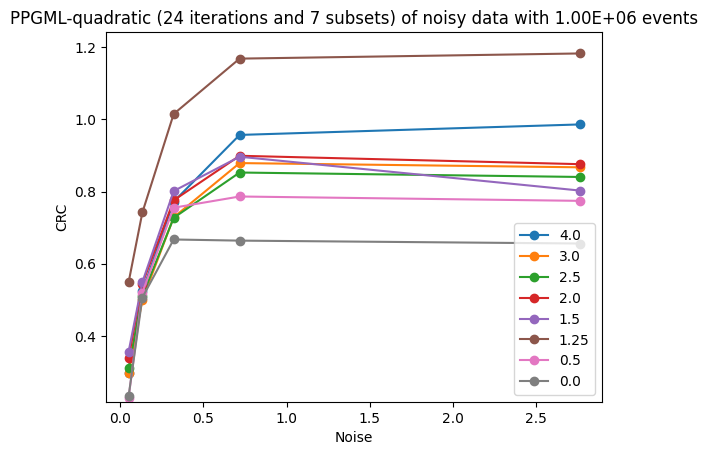

Figure saved in cylinder_1000000e_PPGML-quadratic_s7i24_CRCvsNoise.png


In [8]:
#
# Reconstruction parameters: optimization algorithm, penalty
#
iterNb=24
subsetNb=7
opti='PPGML' # \in ['MLEM','PPGML']
penalty='quadratic' # \in [None,'quadratic','huber','nuyts'] 
bowsher=None # \in [None,1]
#betas=[0,0.0625,0.125,0.25,0.5,1.0,2.0,5.0,9.0]
betas=[0,0.125,0.5,2.0,9.0]
#
#
#
penaltyNb=4            
betaNb=len(betas)
if CRCPPGML is None:
    CRCPPGML = np.zeros((penaltyNb,sphereNb,betaNb))
if NoisePPGML is None:
    NoisePPGML = np.zeros((penaltyNb,betaNb))
#
# Definition of the penalty
#
optiName=opti
if penalty is not None:
    if opti == 'MLEM':
        sys.stderr.write(f'Error: MLEM can not be run with a penalty term ({penalty})')
        sys.exit(1)
    penaltyFile='MRF.conf'
    optiName=optiName+f'-{penalty}'
    with open(penaltyFile,'w',encoding="utf-8") as f:
        if penalty == 'quadratic':
            f.write('potential function: quadratic\n')
            iPenalty=0
        elif penalty == 'huber':
            f.write('potential function: huber piecewise\n')
            f.write('deltaHuber: 0.1\n')
            iPenalty=1
        elif penalty == 'nuyts': 
            f.write('potential function: nuyts relative\n')
            f.write('gammaRD: 2\n') 
            iPenalty=2
        else:
            sys.stderr.write(f'Error: penalty function {penalty} is not recognized')
            sys.exit(1)
        f.write('neighborhood shape: sphere\n')
        f.write('sphere neighborhood radius (mm): 6\n')
        f.write('proximity factor: euclidian\n')
        if bowsher is None:
            f.write('similarity factor: none\n')
        else:
            f.write('similarity factor: aBowsher\n')
            f.write('similarity threshold Bowsher (%): 40.\n')
            optiName=optiName+'-bowsher'
            iPenalty=3
#
# Reconstruction
#
reconName=name+'_'+optiName
reconNoiseDir=f'{workDir}/CASToR-recon-{reconName}'
if not os.path.exists(simulNoiseDataFile):
    sys.stderr.write(f'Error: noisy sinogram  with {eventsNb} data file {simulNoiseDataFile} does not exist')
    sys.exit(1)    
print(f'Reconstructions with {optiName} of the noisy sinogram with {eventsNb:.2E} events')
NbCols=4
NbRows=betaNb
fig, ax = plt.subplots(NbRows,NbCols,figsize=[3*NbCols,3*NbRows])
vmax=1.5*np.max(sphereValues)
iRadius = round(sphereRadius/pixelSize)+1
titleSize=10
row=0
for beta in betas:
    print(f' ... wait for beta = {beta}...')
    cmd=f'{castorDir}/bin/castor-recon -df {simulNoiseDataFile} -dout {reconNoiseDir}-b{beta} -opti {opti} -it {iterNb}:{subsetNb}  {dim} {vox}'
    cmd=f'{cmd} -th 0 -vb 1 {proj} {framing} -proj-common 3,0,0 -conf {castorDir}/config'
    cmd=cmd+f' -pnlt MRF:{penaltyFile} -pnlt-beta {beta}'
    if bowsher is not None:
        cmd=cmd+f' -multimodal {reconAnaFile}'
    args = shlex.split(cmd)
    p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
    p.wait()
    stdout,stderr = p.communicate()
    if p.returncode != 0:
        sys.stderr.write(f'Error with {cmd}:')
        sys.stderr.write(str(stderr.decode('utf-8'))) 
        sys.exit(1)
    reconNoiseFile=f'{reconNoiseDir}-b{beta}/CASToR-recon-{reconName}-b{beta}_it{iterNb}.hdr'
    if not os.path.exists(reconNoiseFile):
        sys.stderr.write(f'Error: reconstruction file of the noisy sinogram with {eventsNb} {reconNoiseFile} does not exist')
        sys.exit(1)
    # figure
    hdr=Interfile.load(f'{phantomImgFileName}.hdr')
    imgPhantom=getNPArrayFromCASToRInterfileHeader(hdr,workDir,strict_enforce=True,Verbose=False)
    imp=ax[row,0].imshow(imgPhantom[0,:,:],vmax=vmax)
    fig.colorbar(imp,ax=ax[row,0])
    ax[row,0].set_axis_off()
    ax[row,0].set_title('Phantom',size=titleSize)
    hdr=Interfile.load(reconNoiseFile)
    imgNoiseRecon=getNPArrayFromCASToRInterfileHeader(hdr,reconNoiseDir+f'-b{beta}',strict_enforce=True,Verbose=False)
    imn=ax[row,1].imshow(imgNoiseRecon[0,:,:],vmax=vmax)
    fig.colorbar(imn,ax=ax[row,1])
    ax[row,1].set_axis_off()
    ax[row,1].set_title(f'Replicate for beta {beta}',size=titleSize)
    imgNoiseReconMean=np.mean(imgNoiseRecon,axis=0)
    imm=ax[row,2].imshow(imgNoiseReconMean,vmax=vmax)
    fig.colorbar(imm,ax=ax[row,2])
    ax[row,2].set_axis_off()
    ax[row,2].set_title(f'Mean',size=titleSize)
    imgNoiseReconStd=np.std(imgNoiseRecon,axis=0)
    if row == 0:
        vmaxStd=0.1*np.max(imgNoiseRecon)
    ims=ax[row,3].imshow(imgNoiseReconStd,vmax=vmaxStd)
    fig.colorbar(ims,ax=ax[row,3])
    ax[row,3].set_axis_off()
    ax[row,3].set_title(f'Standard-deviation',size=titleSize)
    #
    # ROI analysis
    #
    #  Background in the cylinder center
    ixc=round(0.5*pixelNb-0.5)
    iyc=round(0.5*pixelNb-0.5)
    n=0
    roiBackgroundMeanValue=0.0
    roiBackgroundStdValue=0.0
    for ix in range(ixc-iRadius,ixc+iRadius+1,1):
        x = pixelSize*(ix+0.5-pixelNb/2.0)
        for iy in range(iyc-iRadius,iyc+iRadius+1,1):
            y = pixelSize*(iy+0.5-pixelNb/2.0)
            r = math.sqrt((x)**2+(y)**2)
            if r < sphereRadius:
                n+=1
                roiBackgroundMeanValue+=imgNoiseReconMean[iy,ix]
                roiBackgroundStdValue+=imgNoiseReconStd[iy,ix]
    roiBackgroundMeanValue/=n
    roiBackgroundStdValue/=n
    NoisePPGML[iPenalty,row]=roiBackgroundStdValue/roiBackgroundMeanValue
    for i in range(sphereNb):
        ixc=int(round(0.5*pixelNb+sphereCoordinates[i,0]/pixelSize-0.5))
        iyc=int(round(0.5*pixelNb+sphereCoordinates[i,1]/pixelSize-0.5))
        n=0
        roiMeanValue=0.0
        roiStdValue=0.0
        for ix in range(ixc-iRadius,ixc+iRadius+1,1):
            x = pixelSize*(ix+0.5-pixelNb/2.0)
            for iy in range(iyc-iRadius,iyc+iRadius+1,1):
                y = pixelSize*(iy+0.5-pixelNb/2.0)
                r = math.sqrt((x-sphereCoordinates[i,0])**2+(y-sphereCoordinates[i,1])**2)
                if r < 0.9*sphereRadius:
                    n+=1
                    roiMeanValue+=imgNoiseReconMean[iy,ix]
                    roiStdValue+=imgNoiseReconStd[iy,ix]
        roiMeanValue/=n
        roiStdValue/=n
        CRCPPGML[iPenalty,i,row]=(roiMeanValue/roiBackgroundMeanValue-1)/(sphereValues[i]/backgroundValue-1)
    print(f'Beta {beta}, CRC = {CRCPPGML[iPenalty,0,row]}, noise = {NoisePPGML[iPenalty,row]}')
    row+=1
plt.suptitle(f'Reconstruction with {optiName} ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events',y=0.95)
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i{iterNb}.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')
fig, ax = plt.subplots()
for iSphere in range(sphereNb):
    ax.plot(NoisePPGML[iPenalty,:],CRCPPGML[iPenalty,iSphere,:],'o',ls='-',label=f'{sphereValues[iSphere]/backgroundValue}')
ax.set(xlabel='Noise', ylabel='CRC',title=f'{optiName} ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events')
ax.set_ylim((0.95*np.min(CRCPPGML[iPenalty,:,:]),1.05*np.max(CRCPPGML[iPenalty,:,:])))
plt.legend(loc='lower right')
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i{iterNb}_CRCvsNoise.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')

Reconstructions with PPGML-huber of the noisy sinogram with 1.00E+06 events
 ... wait for beta = 0...
Beta 0, CRC = 0.9861354825431631, noise = 2.762949479953279
 ... wait for beta = 0.125...
Beta 0.125, CRC = 0.996105387089978, noise = 2.6984485081437297
 ... wait for beta = 0.5...
Beta 0.5, CRC = 1.027163571146389, noise = 2.4367145653260325
 ... wait for beta = 2.0...
Beta 2.0, CRC = 0.9909960248436581, noise = 0.5288436954842762
 ... wait for beta = 9.0...
Beta 9.0, CRC = 0.6824549291378671, noise = 0.21968011600275608


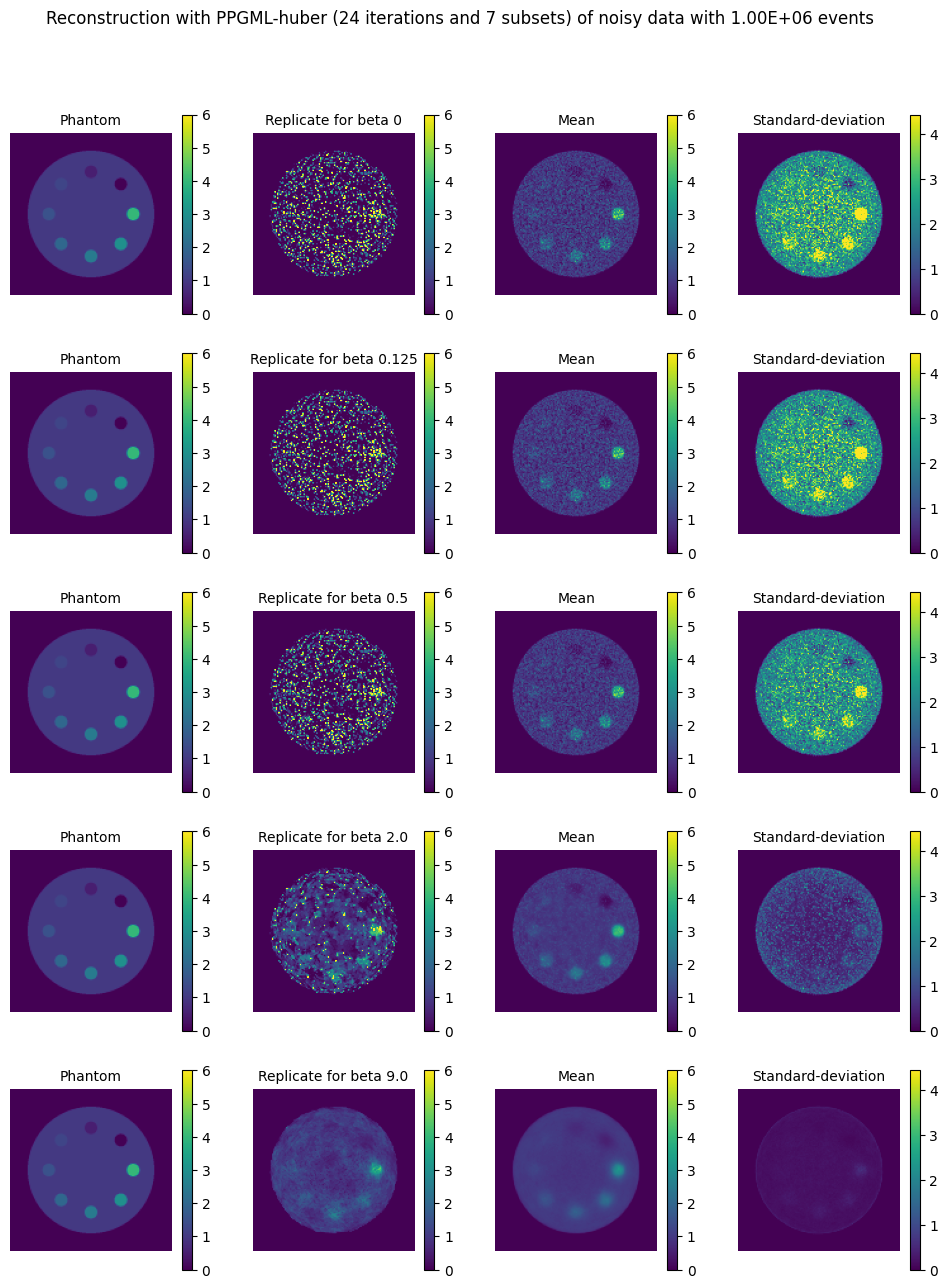

Figure saved in cylinder_1000000e_PPGML-huber_s7i24.png


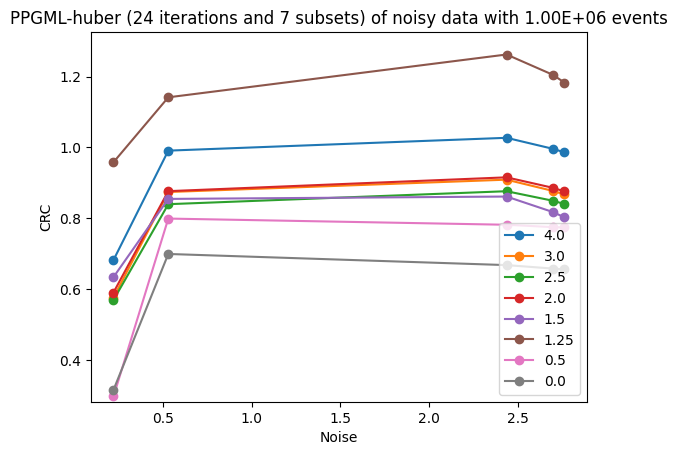

Figure saved in cylinder_1000000e_PPGML-huber_s7i24_CRCvsNoise.png


In [9]:
#
# Reconstruction parameters: optimization algorithm, penalty
#
iterNb=24
subsetNb=7
opti='PPGML' # \in ['MLEM','PPGML']
penalty='huber' # \in [None,'quadratic','huber','nuyts'] 
bowsher=None # \in [None,1]
#betas=[0,0.0625,0.125,0.25,0.5,1.0,2.0,5.0,9.0]
betas=[0,0.125,0.5,2.0,9.0]
#
#
#
penaltyNb=4            
betaNb=len(betas)
if CRCPPGML is None:
    CRCPPGML = np.zeros((penaltyNb,sphereNb,betaNb))
if NoisePPGML is None:
    NoisePPGML = np.zeros((penaltyNb,betaNb))
#
# Definition of the penalty
#
optiName=opti
if penalty is not None:
    if opti == 'MLEM':
        sys.stderr.write(f'Error: MLEM can not be run with a penalty term ({penalty})')
        sys.exit(1)
    penaltyFile='MRF.conf'
    optiName=optiName+f'-{penalty}'
    with open(penaltyFile,'w',encoding="utf-8") as f:
        if penalty == 'quadratic':
            f.write('potential function: quadratic\n')
            iPenalty=0
        elif penalty == 'huber':
            f.write('potential function: huber piecewise\n')
            f.write('deltaHuber: 0.1\n')
            iPenalty=1
        elif penalty == 'nuyts': 
            f.write('potential function: nuyts relative\n')
            f.write('gammaRD: 2\n') 
            iPenalty=2
        else:
            sys.stderr.write(f'Error: penalty function {penalty} is not recognized')
            sys.exit(1)
        f.write('neighborhood shape: sphere\n')
        f.write('sphere neighborhood radius (mm): 6\n')
        f.write('proximity factor: euclidian\n')
        if bowsher is None:
            f.write('similarity factor: none\n')
        else:
            f.write('similarity factor: aBowsher\n')
            f.write('similarity threshold Bowsher (%): 40.\n')
            optiName=optiName+'-bowsher'
            iPenalty=3
#
# Reconstruction
#
reconName=name+'_'+optiName
reconNoiseDir=f'{workDir}/CASToR-recon-{reconName}'
if not os.path.exists(simulNoiseDataFile):
    sys.stderr.write(f'Error: noisy sinogram  with {eventsNb} data file {simulNoiseDataFile} does not exist')
    sys.exit(1)    
print(f'Reconstructions with {optiName} of the noisy sinogram with {eventsNb:.2E} events')
NbCols=4
NbRows=betaNb
fig, ax = plt.subplots(NbRows,NbCols,figsize=[3*NbCols,3*NbRows])
vmax=1.5*np.max(sphereValues)
iRadius = round(sphereRadius/pixelSize)+1
titleSize=10
row=0
for beta in betas:
    print(f' ... wait for beta = {beta}...')
    cmd=f'{castorDir}/bin/castor-recon -df {simulNoiseDataFile} -dout {reconNoiseDir}-b{beta} -opti {opti} -it {iterNb}:{subsetNb}  {dim} {vox}'
    cmd=f'{cmd} -th 0 -vb 1 {proj} {framing} -proj-common 3,0,0 -conf {castorDir}/config'
    cmd=cmd+f' -pnlt MRF:{penaltyFile} -pnlt-beta {beta}'
    if bowsher is not None:
        cmd=cmd+f' -multimodal {reconAnaFile}'
    args = shlex.split(cmd)
    p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
    p.wait()
    stdout,stderr = p.communicate()
    if p.returncode != 0:
        sys.stderr.write(f'Error with {cmd}:')
        sys.stderr.write(str(stderr.decode('utf-8'))) 
        sys.exit(1)
    reconNoiseFile=f'{reconNoiseDir}-b{beta}/CASToR-recon-{reconName}-b{beta}_it{iterNb}.hdr'
    if not os.path.exists(reconNoiseFile):
        sys.stderr.write(f'Error: reconstruction file of the noisy sinogram with {eventsNb} {reconNoiseFile} does not exist')
        sys.exit(1)
    # figure
    hdr=Interfile.load(f'{phantomImgFileName}.hdr')
    imgPhantom=getNPArrayFromCASToRInterfileHeader(hdr,workDir,strict_enforce=True,Verbose=False)
    imp=ax[row,0].imshow(imgPhantom[0,:,:],vmax=vmax)
    fig.colorbar(imp,ax=ax[row,0])
    ax[row,0].set_axis_off()
    ax[row,0].set_title('Phantom',size=titleSize)
    hdr=Interfile.load(reconNoiseFile)
    imgNoiseRecon=getNPArrayFromCASToRInterfileHeader(hdr,reconNoiseDir+f'-b{beta}',strict_enforce=True,Verbose=False)
    imn=ax[row,1].imshow(imgNoiseRecon[0,:,:],vmax=vmax)
    fig.colorbar(imn,ax=ax[row,1])
    ax[row,1].set_axis_off()
    ax[row,1].set_title(f'Replicate for beta {beta}',size=titleSize)
    imgNoiseReconMean=np.mean(imgNoiseRecon,axis=0)
    imm=ax[row,2].imshow(imgNoiseReconMean,vmax=vmax)
    fig.colorbar(imm,ax=ax[row,2])
    ax[row,2].set_axis_off()
    ax[row,2].set_title(f'Mean',size=titleSize)
    imgNoiseReconStd=np.std(imgNoiseRecon,axis=0)
    if row == 0:
        vmaxStd=0.1*np.max(imgNoiseRecon)
    ims=ax[row,3].imshow(imgNoiseReconStd,vmax=vmaxStd)
    fig.colorbar(ims,ax=ax[row,3])
    ax[row,3].set_axis_off()
    ax[row,3].set_title(f'Standard-deviation',size=titleSize)
    #
    # ROI analysis
    #
    #  Background in the cylinder center
    ixc=round(0.5*pixelNb-0.5)
    iyc=round(0.5*pixelNb-0.5)
    n=0
    roiBackgroundMeanValue=0.0
    roiBackgroundStdValue=0.0
    for ix in range(ixc-iRadius,ixc+iRadius+1,1):
        x = pixelSize*(ix+0.5-pixelNb/2.0)
        for iy in range(iyc-iRadius,iyc+iRadius+1,1):
            y = pixelSize*(iy+0.5-pixelNb/2.0)
            r = math.sqrt((x)**2+(y)**2)
            if r < sphereRadius:
                n+=1
                roiBackgroundMeanValue+=imgNoiseReconMean[iy,ix]
                roiBackgroundStdValue+=imgNoiseReconStd[iy,ix]
    roiBackgroundMeanValue/=n
    roiBackgroundStdValue/=n
    NoisePPGML[iPenalty,row]=roiBackgroundStdValue/roiBackgroundMeanValue
    for i in range(sphereNb):
        ixc=int(round(0.5*pixelNb+sphereCoordinates[i,0]/pixelSize-0.5))
        iyc=int(round(0.5*pixelNb+sphereCoordinates[i,1]/pixelSize-0.5))
        n=0
        roiMeanValue=0.0
        roiStdValue=0.0
        for ix in range(ixc-iRadius,ixc+iRadius+1,1):
            x = pixelSize*(ix+0.5-pixelNb/2.0)
            for iy in range(iyc-iRadius,iyc+iRadius+1,1):
                y = pixelSize*(iy+0.5-pixelNb/2.0)
                r = math.sqrt((x-sphereCoordinates[i,0])**2+(y-sphereCoordinates[i,1])**2)
                if r < 0.9*sphereRadius:
                    n+=1
                    roiMeanValue+=imgNoiseReconMean[iy,ix]
                    roiStdValue+=imgNoiseReconStd[iy,ix]
        roiMeanValue/=n
        roiStdValue/=n
        CRCPPGML[iPenalty,i,row]=(roiMeanValue/roiBackgroundMeanValue-1)/(sphereValues[i]/backgroundValue-1)
    print(f'Beta {beta}, CRC = {CRCPPGML[iPenalty,0,row]}, noise = {NoisePPGML[iPenalty,row]}')
    row+=1
plt.suptitle(f'Reconstruction with {optiName} ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events',y=0.95)
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i{iterNb}.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')
fig, ax = plt.subplots()
for iSphere in range(sphereNb):
    ax.plot(NoisePPGML[iPenalty,:],CRCPPGML[iPenalty,iSphere,:],'o',ls='-',label=f'{sphereValues[iSphere]/backgroundValue}')
ax.set(xlabel='Noise', ylabel='CRC',title=f'{optiName} ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events')
ax.set_ylim((0.95*np.min(CRCPPGML[iPenalty,:,:]),1.05*np.max(CRCPPGML[iPenalty,:,:])))
plt.legend(loc='lower right')
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i{iterNb}_CRCvsNoise.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')

Reconstructions with PPGML-nuyts of the noisy sinogram with 1.00E+06 events
 ... wait for beta = 0...
Beta 0, CRC = 0.9861354825431631, noise = 2.762949479953279
 ... wait for beta = 0.125...
Beta 0.125, CRC = 1.022957543890526, noise = 2.4542295985057074
 ... wait for beta = 0.5...
Beta 0.5, CRC = 1.0084147536323302, noise = 0.7639031606546431
 ... wait for beta = 2.0...
Beta 2.0, CRC = 0.7757744848336002, noise = 0.1526385271657255
 ... wait for beta = 9.0...
Beta 9.0, CRC = 0.42114777921325475, noise = 0.05098994062483408


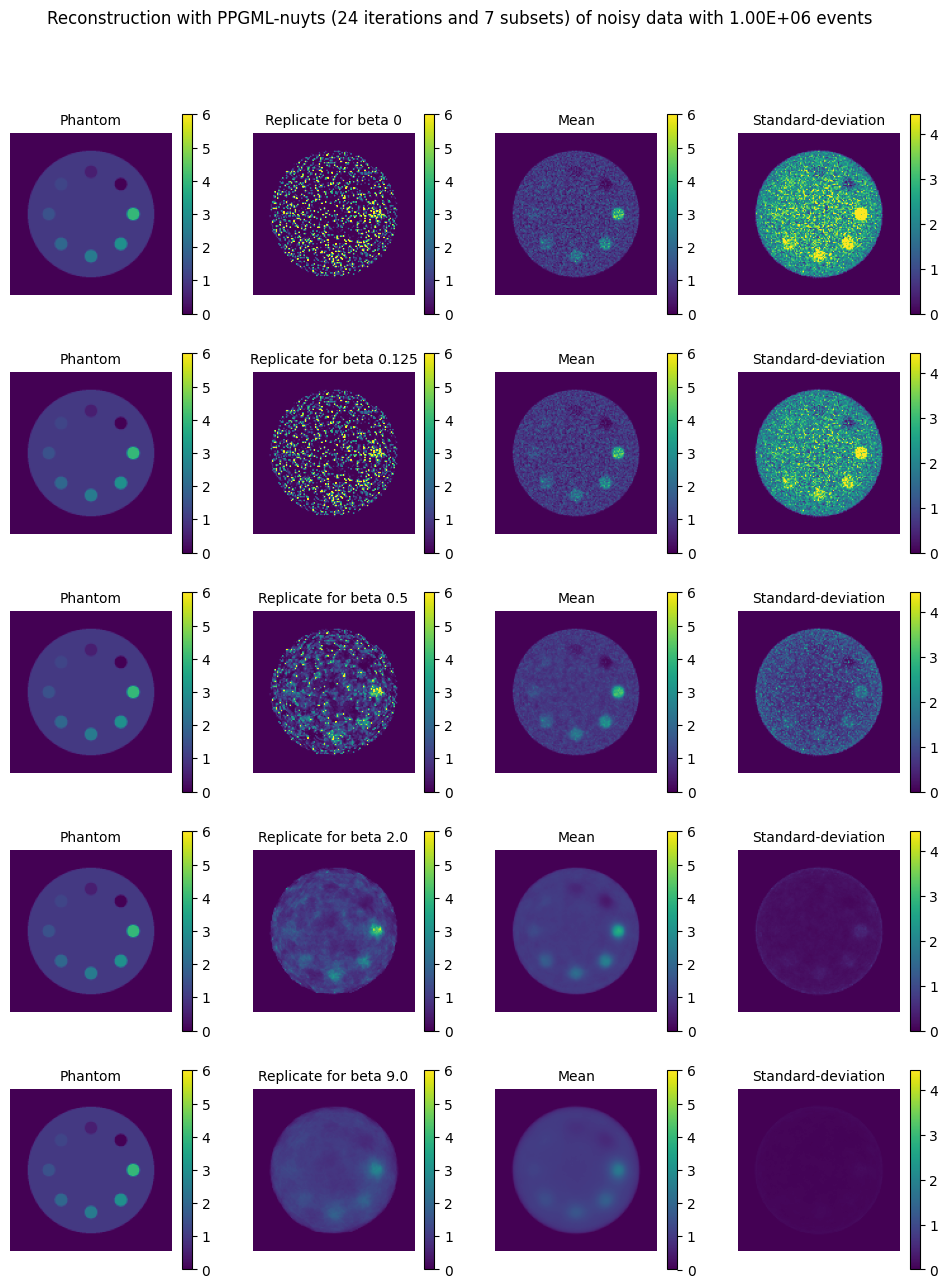

Figure saved in cylinder_1000000e_PPGML-nuyts_s7i24.png


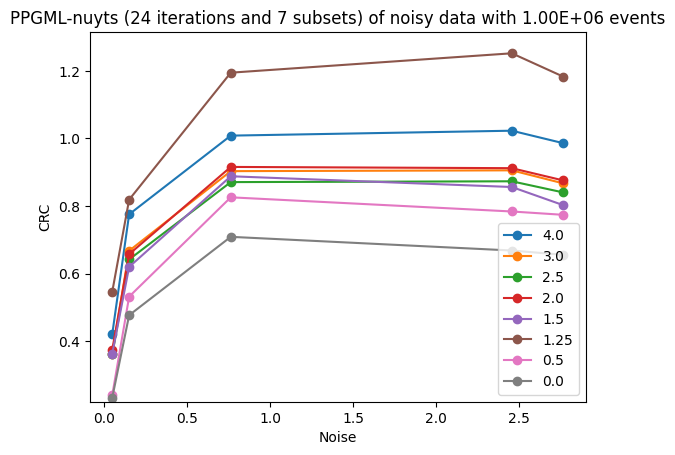

Figure saved in cylinder_1000000e_PPGML-nuyts_s7i24_CRCvsNoise.png


In [12]:
#
# Reconstruction parameters: optimization algorithm, penalty
#
iterNb=24
subsetNb=7
opti='PPGML' # \in ['MLEM','PPGML']
penalty='nuyts'# \in [None,'quadratic','huber','nuyts'] 
bowsher=None # \in [None,1]
#betas=[0,0.0625,0.125,0.25,0.5,1.0,2.0,5.0,9.0]
betas=[0,0.125,0.5,2.0,9.0]
#
#
#
penaltyNb=4            
betaNb=len(betas)
if CRCPPGML is None:
    CRCPPGML = np.zeros((penaltyNb,sphereNb,betaNb))
if NoisePPGML is None:
    NoisePPGML = np.zeros((penaltyNb,betaNb))
#
# Definition of the penalty
#
optiName=opti
if penalty is not None:
    if opti == 'MLEM':
        sys.stderr.write(f'Error: MLEM can not be run with a penalty term ({penalty})')
        sys.exit(1)
    penaltyFile='MRF.conf'
    optiName=optiName+f'-{penalty}'
    with open(penaltyFile,'w',encoding="utf-8") as f:
        if penalty == 'quadratic':
            f.write('potential function: quadratic\n')
            iPenalty=0
        elif penalty == 'huber':
            f.write('potential function: huber piecewise\n')
            f.write('deltaHuber: 0.1\n')
            iPenalty=1
        elif penalty == 'nuyts': 
            f.write('potential function: nuyts relative\n')
            f.write('gammaRD: 2\n') 
            iPenalty=2
        else:
            sys.stderr.write(f'Error: penalty function {penalty} is not recognized')
            sys.exit(1)
        f.write('neighborhood shape: sphere\n')
        f.write('sphere neighborhood radius (mm): 6\n')
        f.write('proximity factor: euclidian\n')
        if bowsher is None:
            f.write('similarity factor: none\n')
        else:
            f.write('similarity factor: aBowsher\n')
            f.write('similarity threshold Bowsher (%): 40.\n')
            optiName=optiName+'-bowsher'
            iPenalty=3
#
# Reconstruction
#
reconName=name+'_'+optiName
reconNoiseDir=f'{workDir}/CASToR-recon-{reconName}'
if not os.path.exists(simulNoiseDataFile):
    sys.stderr.write(f'Error: noisy sinogram  with {eventsNb} data file {simulNoiseDataFile} does not exist')
    sys.exit(1)    
print(f'Reconstructions with {optiName} of the noisy sinogram with {eventsNb:.2E} events')
NbCols=4
NbRows=betaNb
fig, ax = plt.subplots(NbRows,NbCols,figsize=[3*NbCols,3*NbRows])
vmax=1.5*np.max(sphereValues)
iRadius = round(sphereRadius/pixelSize)+1
titleSize=10
row=0
for beta in betas:
    print(f' ... wait for beta = {beta}...')
    cmd=f'{castorDir}/bin/castor-recon -df {simulNoiseDataFile} -dout {reconNoiseDir}-b{beta} -opti {opti} -it {iterNb}:{subsetNb}  {dim} {vox}'
    cmd=f'{cmd} -th 0 -vb 1 {proj} {framing} -proj-common 3,0,0 -conf {castorDir}/config'
    cmd=cmd+f' -pnlt MRF:{penaltyFile} -pnlt-beta {beta}'
    if bowsher is not None:
        cmd=cmd+f' -multimodal {reconAnaFile}'
    args = shlex.split(cmd)
    p = subprocess.Popen(args,stderr=subprocess.PIPE,stdout=subprocess.PIPE)
    p.wait()
    stdout,stderr = p.communicate()
    if p.returncode != 0:
        sys.stderr.write(f'Error with {cmd}:')
        sys.stderr.write(str(stderr.decode('utf-8'))) 
        sys.exit(1)
    reconNoiseFile=f'{reconNoiseDir}-b{beta}/CASToR-recon-{reconName}-b{beta}_it{iterNb}.hdr'
    if not os.path.exists(reconNoiseFile):
        sys.stderr.write(f'Error: reconstruction file of the noisy sinogram with {eventsNb} {reconNoiseFile} does not exist')
        sys.exit(1)
    # figure
    hdr=Interfile.load(f'{phantomImgFileName}.hdr')
    imgPhantom=getNPArrayFromCASToRInterfileHeader(hdr,workDir,strict_enforce=True,Verbose=False)
    imp=ax[row,0].imshow(imgPhantom[0,:,:],vmax=vmax)
    fig.colorbar(imp,ax=ax[row,0])
    ax[row,0].set_axis_off()
    ax[row,0].set_title('Phantom',size=titleSize)
    hdr=Interfile.load(reconNoiseFile)
    imgNoiseRecon=getNPArrayFromCASToRInterfileHeader(hdr,reconNoiseDir+f'-b{beta}',strict_enforce=True,Verbose=False)
    imn=ax[row,1].imshow(imgNoiseRecon[0,:,:],vmax=vmax)
    fig.colorbar(imn,ax=ax[row,1])
    ax[row,1].set_axis_off()
    ax[row,1].set_title(f'Replicate for beta {beta}',size=titleSize)
    imgNoiseReconMean=np.mean(imgNoiseRecon,axis=0)
    imm=ax[row,2].imshow(imgNoiseReconMean,vmax=vmax)
    fig.colorbar(imm,ax=ax[row,2])
    ax[row,2].set_axis_off()
    ax[row,2].set_title(f'Mean',size=titleSize)
    imgNoiseReconStd=np.std(imgNoiseRecon,axis=0)
    if row == 0:
        vmaxStd=0.1*np.max(imgNoiseRecon)
    ims=ax[row,3].imshow(imgNoiseReconStd,vmax=vmaxStd)
    fig.colorbar(ims,ax=ax[row,3])
    ax[row,3].set_axis_off()
    ax[row,3].set_title(f'Standard-deviation',size=titleSize)
    #
    # ROI analysis
    #
    #  Background in the cylinder center
    ixc=round(0.5*pixelNb-0.5)
    iyc=round(0.5*pixelNb-0.5)
    n=0
    roiBackgroundMeanValue=0.0
    roiBackgroundStdValue=0.0
    for ix in range(ixc-iRadius,ixc+iRadius+1,1):
        x = pixelSize*(ix+0.5-pixelNb/2.0)
        for iy in range(iyc-iRadius,iyc+iRadius+1,1):
            y = pixelSize*(iy+0.5-pixelNb/2.0)
            r = math.sqrt((x)**2+(y)**2)
            if r < sphereRadius:
                n+=1
                roiBackgroundMeanValue+=imgNoiseReconMean[iy,ix]
                roiBackgroundStdValue+=imgNoiseReconStd[iy,ix]
    roiBackgroundMeanValue/=n
    roiBackgroundStdValue/=n
    NoisePPGML[iPenalty,row]=roiBackgroundStdValue/roiBackgroundMeanValue
    for i in range(sphereNb):
        ixc=int(round(0.5*pixelNb+sphereCoordinates[i,0]/pixelSize-0.5))
        iyc=int(round(0.5*pixelNb+sphereCoordinates[i,1]/pixelSize-0.5))
        n=0
        roiMeanValue=0.0
        roiStdValue=0.0
        for ix in range(ixc-iRadius,ixc+iRadius+1,1):
            x = pixelSize*(ix+0.5-pixelNb/2.0)
            for iy in range(iyc-iRadius,iyc+iRadius+1,1):
                y = pixelSize*(iy+0.5-pixelNb/2.0)
                r = math.sqrt((x-sphereCoordinates[i,0])**2+(y-sphereCoordinates[i,1])**2)
                if r < 0.9*sphereRadius:
                    n+=1
                    roiMeanValue+=imgNoiseReconMean[iy,ix]
                    roiStdValue+=imgNoiseReconStd[iy,ix]
        roiMeanValue/=n
        roiStdValue/=n
        CRCPPGML[iPenalty,i,row]=(roiMeanValue/roiBackgroundMeanValue-1)/(sphereValues[i]/backgroundValue-1)
    print(f'Beta {beta}, CRC = {CRCPPGML[iPenalty,0,row]}, noise = {NoisePPGML[iPenalty,row]}')
    row+=1
plt.suptitle(f'Reconstruction with {optiName} ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events',y=0.95)
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i{iterNb}.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')
fig, ax = plt.subplots()
for iSphere in range(sphereNb):
    ax.plot(NoisePPGML[iPenalty,:],CRCPPGML[iPenalty,iSphere,:],'o',ls='-',label=f'{sphereValues[iSphere]/backgroundValue}')
ax.set(xlabel='Noise', ylabel='CRC',title=f'{optiName} ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events')
ax.set_ylim((0.95*np.min(CRCPPGML[iPenalty,:,:]),1.05*np.max(CRCPPGML[iPenalty,:,:])))
plt.legend(loc='lower right')
fName=f'{phantom}_{eventsNb}e_{optiName}_s{subsetNb}i{iterNb}_CRCvsNoise.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')

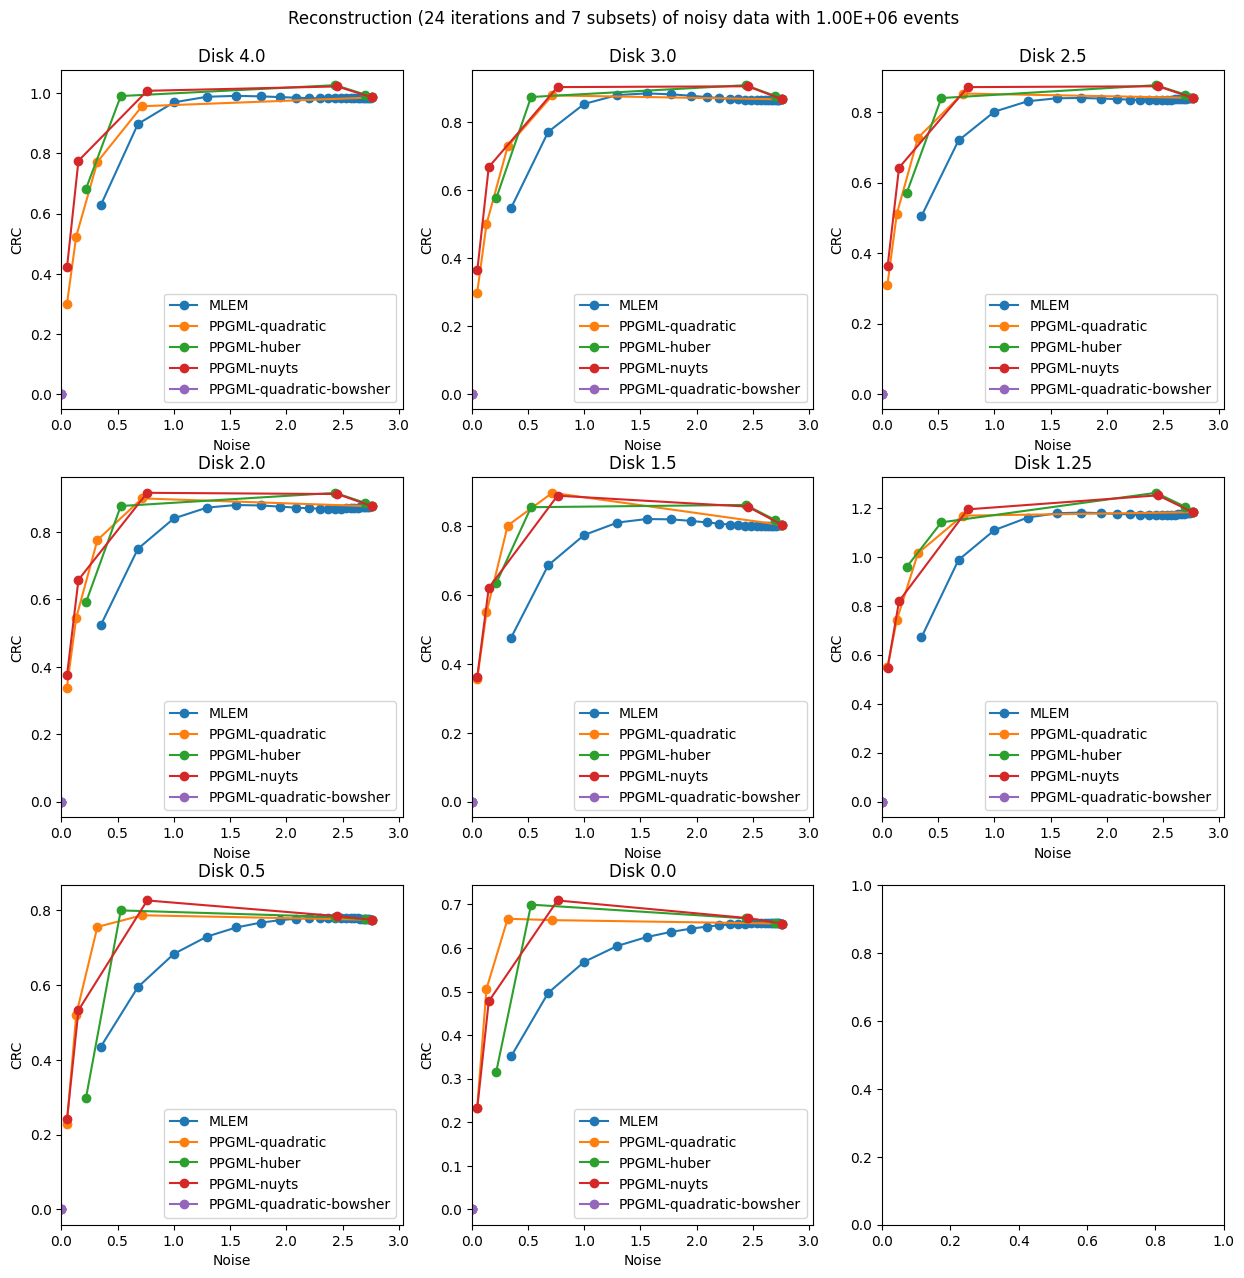

Figure saved in cylinder_1000000e_s7i24_CRCvsNoise.png


In [14]:
nCol=3
nRow=math.ceil(sphereNb/nCol)
fig, ax = plt.subplots(nRow,nCol,figsize=[5*nCol,5*nRow])
xmin=0.9*np.min([np.min(NoisePPGML),np.min(NoiseMLEM)])
xmin=0
xmax=1.1*np.max([np.max(NoisePPGML),np.max(NoiseMLEM)])
for i in range(sphereNb):
    iRow=math.floor(i/nRow)
    iCol=i-iRow*nRow
    ax[iRow,iCol].plot(NoiseMLEM[:],CRCMLEM[i,:],'o',ls='-',label='MLEM')
    ax[iRow,iCol].plot(NoisePPGML[0,:],CRCPPGML[0,i,:],'o',ls='-',label='PPGML-quadratic')
    ax[iRow,iCol].plot(NoisePPGML[1,:],CRCPPGML[1,i,:],'o',ls='-',label='PPGML-huber')
    ax[iRow,iCol].plot(NoisePPGML[2,:],CRCPPGML[2,i,:],'o',ls='-',label='PPGML-nuyts')
    ax[iRow,iCol].plot(NoisePPGML[3,:],CRCPPGML[3,i,:],'o',ls='-',label='PPGML-quadratic-bowsher')
    ax[iRow,iCol].set(xlabel='Noise', ylabel='CRC',title=f'Disk {sphereValues[i]/backgroundValue}')
    # ax[iRow,iCol].set_ylim((0.95*np.min(CRCPPGML),1.05*np.max(CRCPPGML)))
    #ax[iRow,iCol].set_ylim(0.0,1.2)
    ax[iRow,iCol].set_xlim(xmin,xmax)
    ax[iRow,iCol].legend(loc='lower right')
fig.suptitle(f'Reconstruction ({iterNb} iterations and {subsetNb} subsets) of noisy data with {eventsNb:.2E} events',y=0.92)
fName=f'{phantom}_{eventsNb}e_s{subsetNb}i{iterNb}_CRCvsNoise.png'
plt.savefig(fName)
plt.show()
print(f'Figure saved in {fName}')